In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from PIL import Image
import os
from sklearn.model_selection import train_test_split
import zipfile

In [23]:
zip_path = r"C:\Users\Admin\Downloads\img_align_celeba.zip"

In [24]:
zip_path = r"C:\Users\Admin\Downloads\img_align_celeba.zip"
zip_file = zipfile.ZipFile(zip_path, "r")
images = []
for file in zip_file.namelist():
    if file.lower().endswith(".jpg"):
        img = Image.open(
            zip_file.open(file)
        ).convert("RGB")
        img = img.resize((28, 28))
        images.append(np.array(img))
        if len(images) == 5000:
            break
x = np.array(images)
print("Images:", x.shape)

Images: (5000, 28, 28, 3)


In [25]:
x = x.astype("float32") / 255.0
x_train, x_test = train_test_split(
    x,
    test_size=0.2,
    random_state=42
)
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (4000, 28, 28, 3)
Testing images: (1000, 28, 28, 3)


In [26]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
print("Training image shape:", x_train.shape)

Training image shape: (4000, 28, 28, 3, 1)


In [27]:
encoder = Sequential([
    layers.Input(shape=(28, 28, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2))
])

In [32]:
decoder = Sequential([
    layers.Conv2DTranspose(64, (3, 3), strides=2,
                           activation="relu", padding="same"),
    layers.Conv2DTranspose(32, (3, 3), strides=2,
                           activation="relu", padding="same"),
    layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same")
])

In [33]:
autoencoder = models.Sequential([
    encoder,
    decoder
])

In [34]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
    
)

In [35]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.6501 - val_loss: 0.5697
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.5466 - val_loss: 0.5319
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.5261 - val_loss: 0.5203


In [36]:
reconstructed=autoencoder.predict(x_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


In [37]:
print("Minimum",reconstructed.min())
print("Maximum",reconstructed.max())
print("Mean",reconstructed.mean())

Minimum 0.017929718
Maximum 0.9621501
Mean 0.41885015


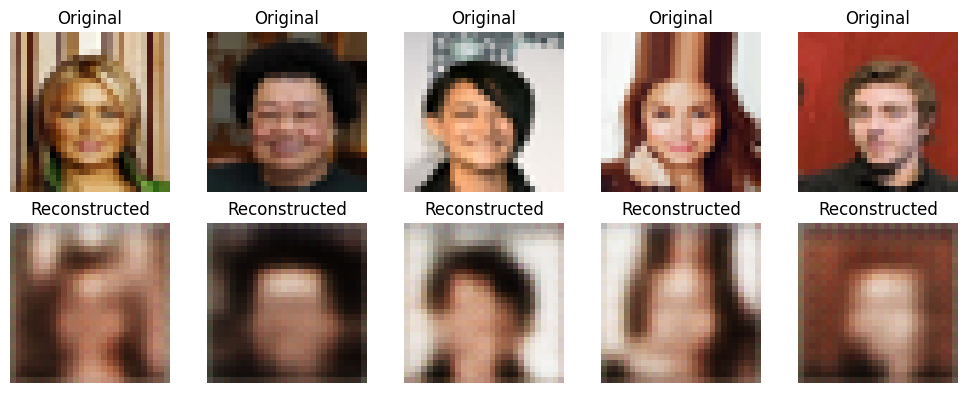

In [38]:
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].squeeze(),cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i].squeeze(),cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")
plt.tight_layout()
plt.show()